# Análisis Exploratorio de Datos (EDA) y Limpieza de Datos para Machine Learning

**Fecha:** Septiembre 2026

**Dataset:** Kaggle / Telco Customer Churn

## 1. Introducción y Objetivos del Proyecto

Este proyecto tiene como objetivo realizar un análisis exploratorio de datos (EDA) y una limpieza exhaustiva sobre un conjunto de datos de clientes de telecomunicaciones. El propósito es identificar patrones, características clave y factores que contribuyen a la rotación de clientes (churn), sentando las bases para futuros modelos de Machine Learning.

**Objetivo Principal:** Identificar factores que influyen en el 'Churn' de clientes de telecomunicaciones.

**Variable Objetivo (Target):** `Churn` (Categórica / Binaria).

**Tipo de Problema ML:** Clasificación Supervisada.

## 2. Configuración del Entorno y Carga de Datos

En esta sección importamos las librerías necesarias agrupadas por función y cargamos el dataset de forma limpia.

In [224]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos (estilo limpio y profesional)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Inspección Inicial (Primer Vistazo)

Antes de modificar algo, necesitamos entender a qué nos enfrentamos. Buscamos tipos de datos erróneos y un resumen estadístico rápido.

In [225]:
# Instala el cliente de la API de Kaggle si aún no está instalado.
!pip install kaggle --upgrade

# Dataset slug from Kaggle URL
dataset_slug = 'blastchar/telco-customer-churn'

# Descarga el conjunto de datos usando la API de Kaggle.
!kaggle datasets download -d {dataset_slug} --unzip

# Cargar el conjunto de datos
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Mostrar las primeras 5 filas
display(df.head())

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 99.1MB/s]



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [226]:
# Información general de tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [227]:
# Resumen estadístico de variables numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## 4. Limpieza de Datos (Data Cleaning)

Aquí tomamos decisiones de diseño. Explicamos por qué eliminamos o imputamos datos, evitando automatizar sin criterio. Un paso crucial es la **unificación de valores nulos y vacíos**: cualquier cadena de texto que represente un valor ausente (como espacios en blanco o ' ') será convertida consistentemente a `np.nan` para facilitar su tratamiento.

In [228]:
# 1. Eliminar la columna customerID (no es necesaria para el análisis)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("Columna 'customerID' eliminada.")
else:
    print("La columna 'customerID' no se encontró o ya ha sido eliminada.")

# 2. Unificar representación de valores nulos/vacíos en columnas de tipo 'object'
# Convertir espacios en blanco o strings vacías a NaN para facilitar su detección y tratamiento.
print("\nVerificando y unificando valores vacíos en columnas de texto...")
for col in df.select_dtypes(include='object').columns:
    # Reemplazar valores que son solo espacios en blanco o cadenas vacías por NaN
    # Usamos .str.strip() para manejar espacios alrededor de cadenas vacías
    initial_nulls = df[col].isnull().sum()
    # Contar filas que contengan solo espacios en blanco (incluidas las cadenas vacías).
    initial_blanks = df[col].astype(str).str.fullmatch(r'\s*').sum()

    if initial_blanks > 0:
        df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)
        print(f"  - En la columna '{col}', se convirtieron {initial_blanks} valores en blanco a NaN.")

    # Comprueba si todavía hay cadenas '' que no fueron detectadas por la expresión regular debido a problemas de conversión de tipos.
    # O si hay representación de cadena 'nan'
    df[col] = df[col].replace([' ', 'nan', 'NaN'], np.nan, regex=False)

    final_nulls = df[col].isnull().sum()
    if final_nulls > initial_nulls:
        print(f"  - En la columna '{col}', se convirtieron {final_nulls - initial_nulls} valores adicionales (ej: ' ' o 'nan') a NaN.")

# 5. Revisar duplicados
duplicados = df.duplicated().sum()
print(f"\nCantidad de filas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()
    print("Filas duplicadas eliminadas.")
else:
    print("No se encontraron filas duplicadas.")

print("\nRecuento final de valores nulos por variable:")
nulos_por_variable = df.isnull().sum()
print(nulos_por_variable)

print("\nLimpieza inicial del DataFrame completada.")

Columna 'customerID' eliminada.

Verificando y unificando valores vacíos en columnas de texto...
  - En la columna 'TotalCharges', se convirtieron 11 valores en blanco a NaN.
  - En la columna 'TotalCharges', se convirtieron 11 valores adicionales (ej: ' ' o 'nan') a NaN.

Cantidad de filas duplicadas encontradas: 22
Filas duplicadas eliminadas.

Recuento final de valores nulos por variable:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Limpieza inicial del DataFrame completada.


In [229]:
# Filtra y muestra las filas con nulos en 'TotalCharges'
filas_nulas = df[df['TotalCharges'].isnull()]
print(filas_nulas)


      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
488   Female              0     Yes        Yes       0           No   
753     Male              0      No        Yes       0          Yes   
936   Female              0     Yes        Yes       0          Yes   
1082    Male              0     Yes        Yes       0          Yes   
1340  Female              0     Yes        Yes       0           No   
3331    Male              0     Yes        Yes       0          Yes   
3826    Male              0     Yes        Yes       0          Yes   
4380  Female              0     Yes        Yes       0          Yes   
5218    Male              0     Yes        Yes       0          Yes   
6670  Female              0     Yes        Yes       0          Yes   
6754    Male              0      No        Yes       0          Yes   

         MultipleLines InternetService       OnlineSecurity  \
488   No phone service             DSL                  Yes   
753                 N

In [230]:
# Obtiene la lista de índices de las filas con nulos
indices_nulos = df[df['TotalCharges'].isnull()].index
print(indices_nulos)


Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')


### 4.1. Análisis de `TotalCharges` (Pre-imputación)

Antes de imputar `TotalCharges`, vamos a re-evaluar su distribución. Como se observó anteriormente, esta columna se carga como tipo `object` y contiene espacios en blanco que deben convertirse a `NaN` para poderla analizar como numérica.

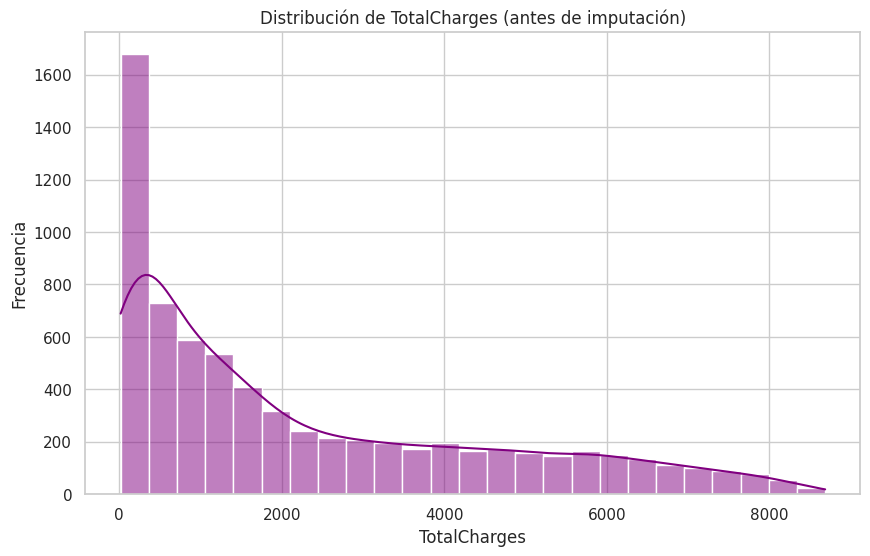

Estadísticas descriptivas de TotalCharges (antes de imputación):


,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


Sesgo de TotalCharges: 0.961642499724251


In [231]:
# Re-cargar el dataset para un análisis previo a la imputación de 'TotalCharges'
# Esto asegura que comenzamos con el estado original de la columna 'TotalCharges'
df_original_for_analysis = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convertir 'TotalCharges' a numérico, forzando los espacios en blanco a NaN
df_original_for_analysis['TotalCharges'] = pd.to_numeric(df_original_for_analysis['TotalCharges'], errors='coerce')

# Analizar la distribución de 'TotalCharges' ANTES de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df_original_for_analysis['TotalCharges'].dropna(), kde=True, color='purple')
plt.title('Distribución de TotalCharges (antes de imputación)')
plt.xlabel('TotalCharges')
plt.ylabel('Frecuencia')
plt.show()

print("Estadísticas descriptivas de TotalCharges (antes de imputación):")
display(df_original_for_analysis['TotalCharges'].describe())

print("Sesgo de TotalCharges:", df_original_for_analysis['TotalCharges'].skew())

### 4.2. Decisiones de Imputación y Chequeo de Categóricas

**Para `TotalCharges`:**

Observando el histograma y el valor del sesgo (skewness) de `TotalCharges`, la distribución está **sesgada a la derecha**. Esto significa que hay una cola más larga de valores altos. En estos casos, la **mediana** es una medida de tendencia central más robusta que la media, ya que es menos sensible a los valores extremos y al sesgo.

**Para Columnas Categóricas:**

Cualquier valor nulo en columnas categóricas se imputará con la **moda** (el valor más frecuente) de esa columna. Procederemos a verificar si existen y aplicar la imputación si es necesario.

### 4.3. Aplicación de la Limpieza de NaN

Con las decisiones de imputación claras y el chequeo de nulos categóricos realizado, procedemos con la imputación de `TotalCharges` con la mediana.

In [232]:
# 3. Convertir TotalCharges a numérico, forzando errores y tratando los nulos
# Los valores ' ' (espacios en blanco) ya deberían haberse convertido a NaN en el paso anterior.
# pd.to_numeric(errors='coerce') también maneja cualquier valor no numérico a NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4. Tratar los nulos en TotalCharges: rellenar con la mediana debido a su distribución sesgada.
# Se usa la mediana porque la distribución de TotalCharges está sesgada a la derecha.
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [233]:
# Identificar columnas categóricas con nulos para imputación por moda
categorical_cols_with_nan = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

if categorical_cols_with_nan:
    print(f"Columnas categóricas con valores nulos: {categorical_cols_with_nan}")
    for col in categorical_cols_with_nan:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Columna '{col}' imputada con la moda: {mode_value}")
else:
    print("No se encontraron columnas categóricas con valores nulos.")

# Re-verificar los nulos después de la imputación categórica
print("\nValores nulos después de imputación categórica:")
display(df.isnull().sum()[df.isnull().sum() > 0])

No se encontraron columnas categóricas con valores nulos.

Valores nulos después de imputación categórica:


,0


##  5. Análisis Exploratorio de Datos (EDA)

El corazón del análisis. Dividimos el estudio en tres partes para no abrumar al lector.

### 5.1. Análisis de la Variable Objetivo (Target)

Es fundamental entender cómo se distribuye lo que queremos predecir, en este caso, la rotación de clientes (`Churn`).

/tmp/ipykernel_692/3496684532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


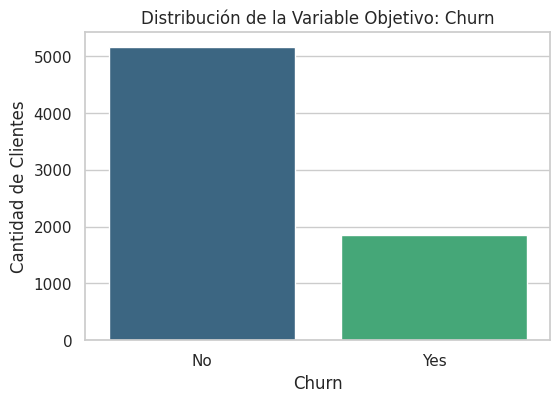

Distribución de la variable Churn:


,count
Churn,
No,5164
Yes,1857


Frecuencia de la variable Churn (%):



,proportion
Churn,
No,73.550776
Yes,26.449224


In [234]:
# Análisis de la variable objetivo Churn (distribución y frecuencia)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de la Variable Objetivo: Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.show()

print("Distribución de la variable Churn:")
display(df['Churn'].value_counts())
print("Frecuencia de la variable Churn (%):\n")
display(df['Churn'].value_counts(normalize=True) * 100)

### 5.2. Análisis de Variables Numéricas (Características / Features)

Examinamos las distribuciones de las variables numéricas para identificar sesgos, asimetrías o posibles outliers. Los histogramas nos permiten visualizar la forma de la distribución, mientras que los boxplots son útiles para detectar valores atípicos y la dispersión de los datos.

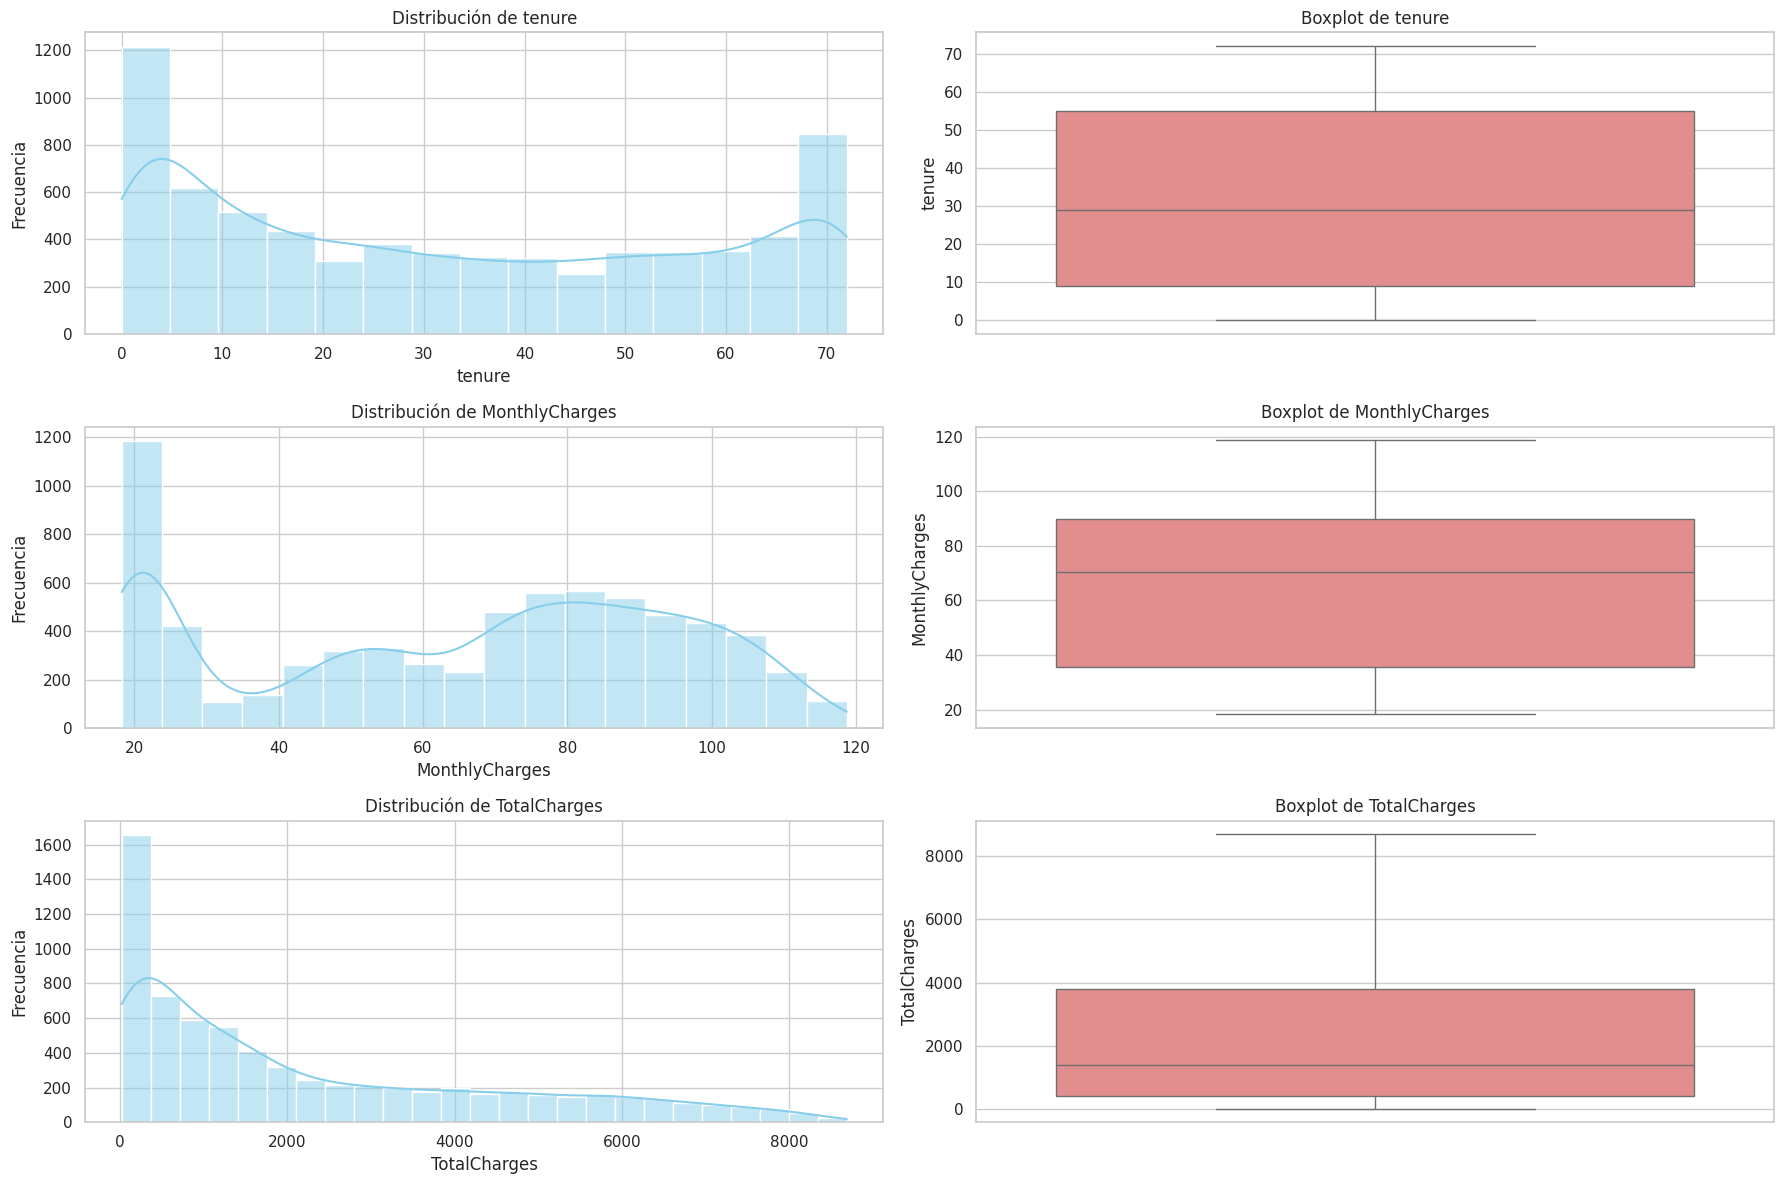

In [235]:
# Histogramas y boxplots para tenure, MonthlyCharges y TotalCharges
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    # Histograma
    plt.subplot(len(numeric_cols), 2, i*2-1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(len(numeric_cols), 2, i*2)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### 5.3. Análisis de Variables Categóricas

Analizamos cómo se distribuyen las variables categóricas y su relación con la variable objetivo `Churn`.

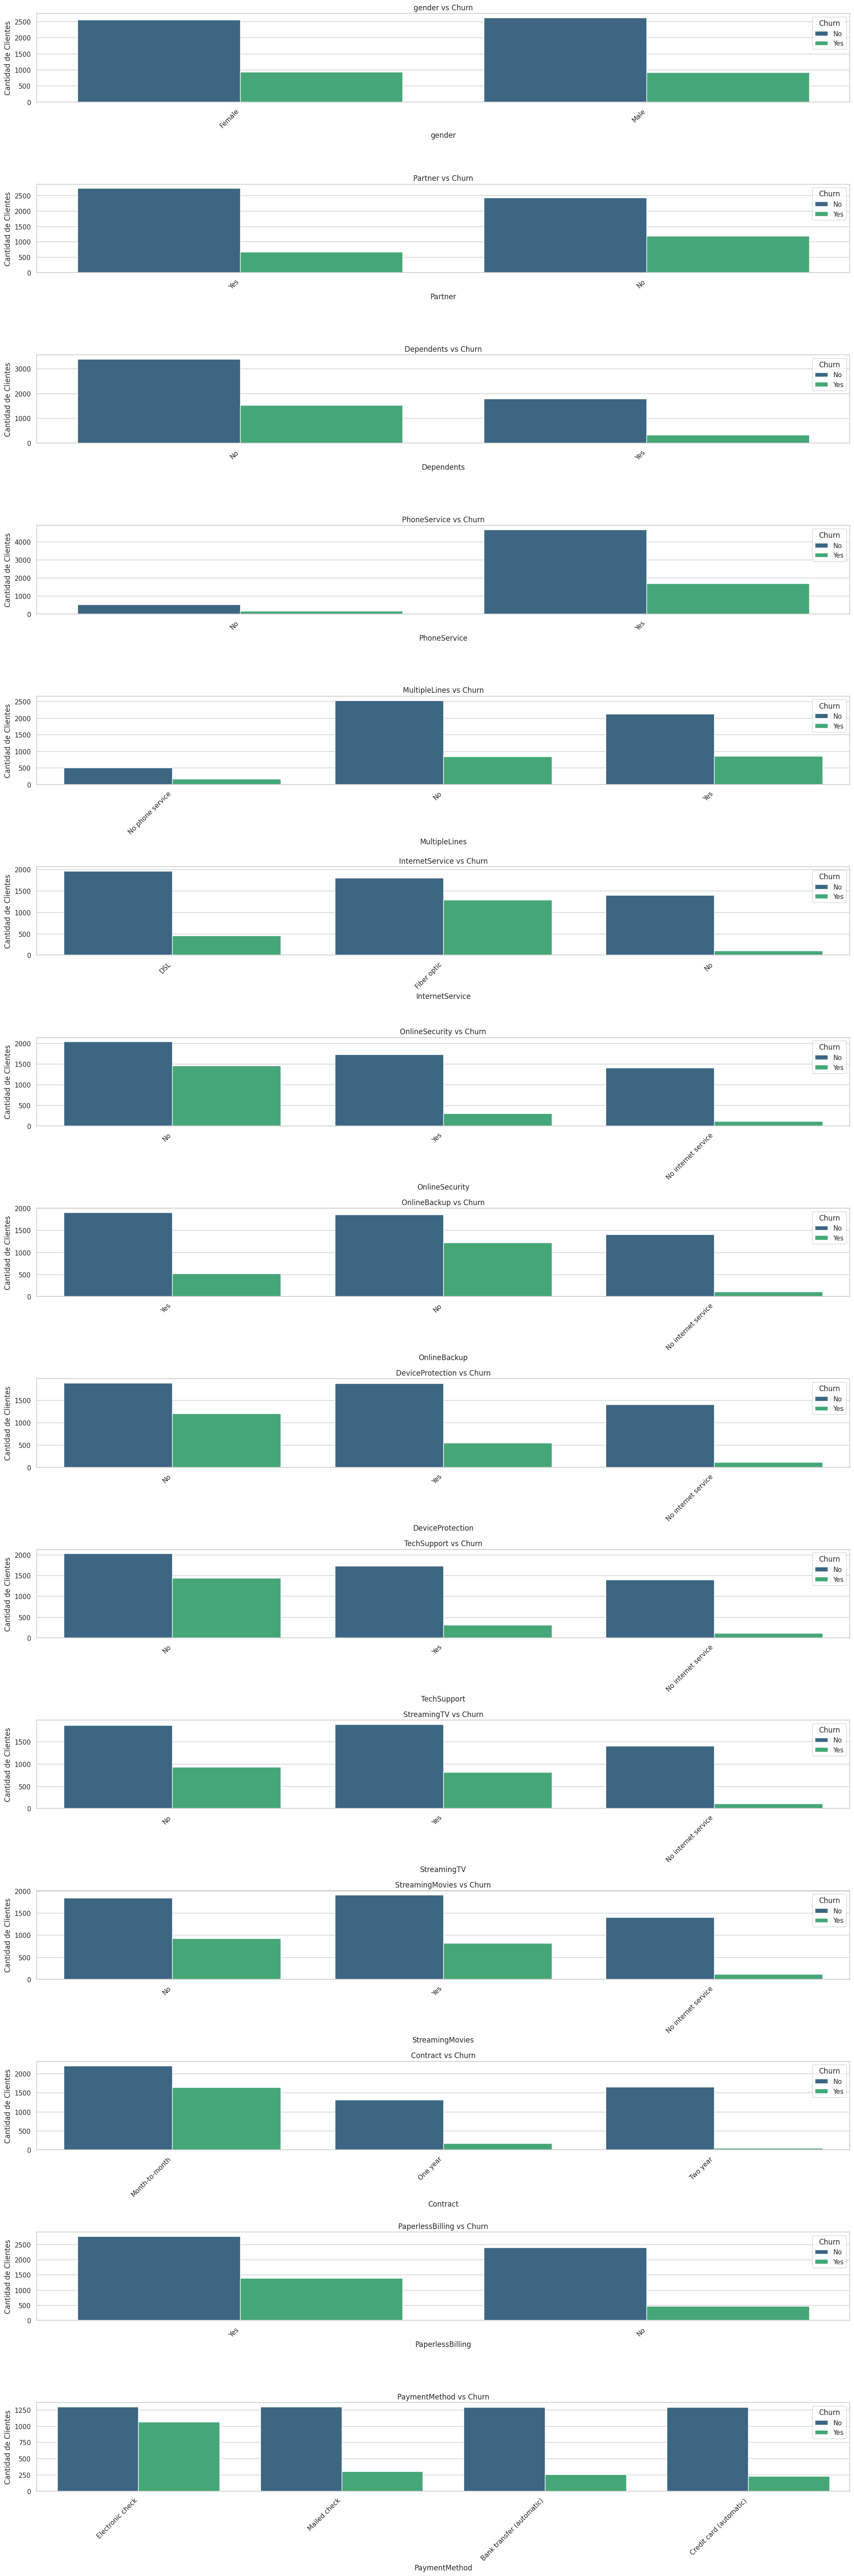

In [236]:
# Gráficos de barras para variables categóricas contra Churn
categorical_cols = df.select_dtypes(include='object').columns.drop('Churn') # Excluir Churn de las categóricas para el bucle

plt.figure(figsize=(20, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5.3.1. Relación entre Variables Categóricas y Numéricas

Aquí visualizamos cómo se distribuyen las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) en función de las categorías de `Churn`, usando boxplots segmentados. Esto nos permite identificar si hay diferencias significativas en estas distribuciones entre clientes que rotan y los que no.

/tmp/ipykernel_692/3198388428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='pastel')
/tmp/ipykernel_692/3198388428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='pastel')
/tmp/ipykernel_692/3198388428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='pastel')


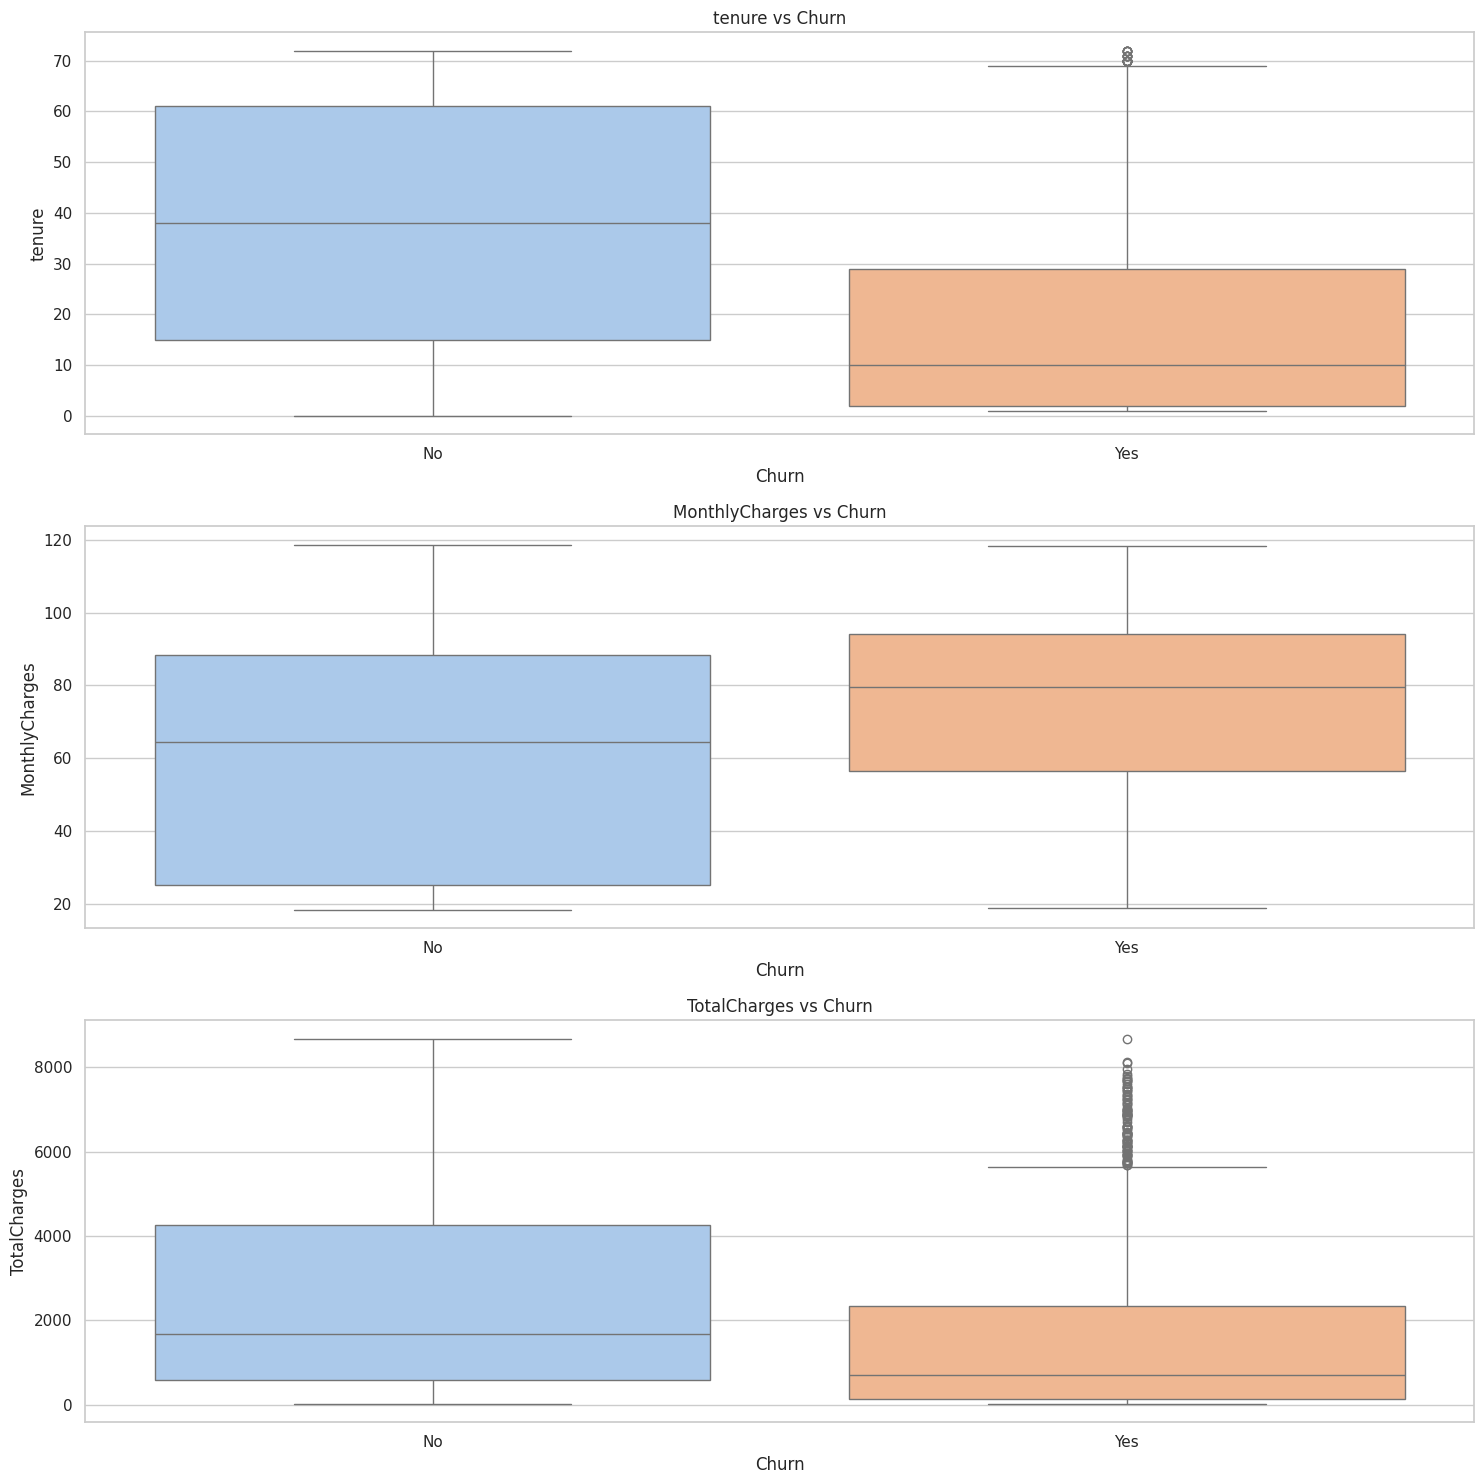

In [237]:
# Boxplots de variables numéricas vs. Churn
numeric_cols_for_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5 * len(numeric_cols_for_eda)))
for i, col in enumerate(numeric_cols_for_eda, 1):
    plt.subplot(len(numeric_cols_for_eda), 1, i)
    # Se añade hue='Churn' para aplicar correctamente la paleta a la variable de agrupamiento.
    # legend=False se añade para evitar una leyenda redundante ya que 'Churn' ya está en el eje x.
    sns.boxplot(data=df, x='Churn', y=col, palette='pastel', hue='Churn', legend=False)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### 5.3.2. Relación entre Variables Categóricas

Para entender las interacciones entre variables categóricas, podemos usar tablas de contingencia (`pd.crosstab`) y visualizarlas con gráficos de barras apiladas. Esto nos ayuda a ver la distribución de una variable categórica dentro de las categorías de otra.


Tabla de Contingencia: Contrato vs Churn


Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


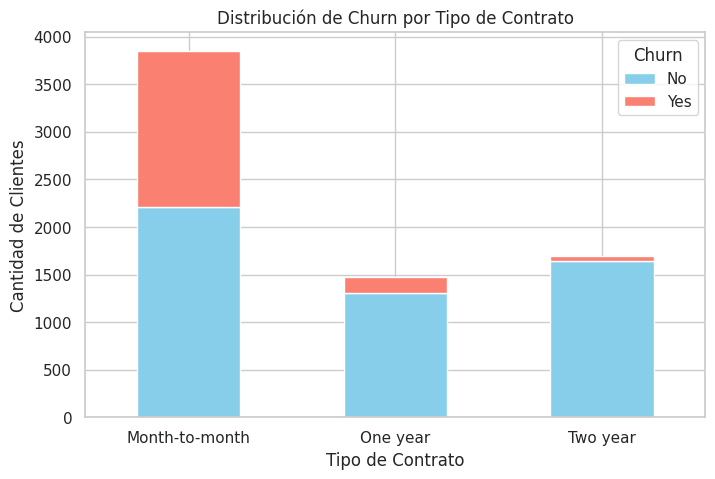


Tabla de Contingencia: Servicio de Internet vs Churn


Churn,No,Yes
InternetService,,
DSL,1962,457
Fiber optic,1799,1291
No,1403,109


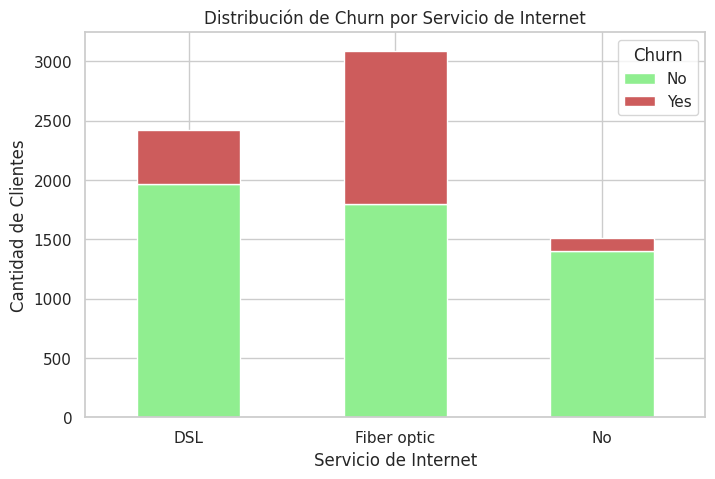

In [238]:
# Ejemplos de tablas de contingencia y gráficos de barras apiladas

# Relación entre 'Contract' y 'Churn'
print("\nTabla de Contingencia: Contrato vs Churn")
crosstab_contract_churn = pd.crosstab(df['Contract'], df['Churn'])
display(crosstab_contract_churn)

crosstab_contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

# Relación entre 'InternetService' y 'Churn'
print("\nTabla de Contingencia: Servicio de Internet vs Churn")
crosstab_internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
display(crosstab_internet_churn)

crosstab_internet_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['lightgreen', 'indianred'])
plt.title('Distribución de Churn por Servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 5.4. Análisis de Correlaciones y Relaciones

Visualizamos la matriz de correlación entre las variables numéricas para entender sus interdependencias.

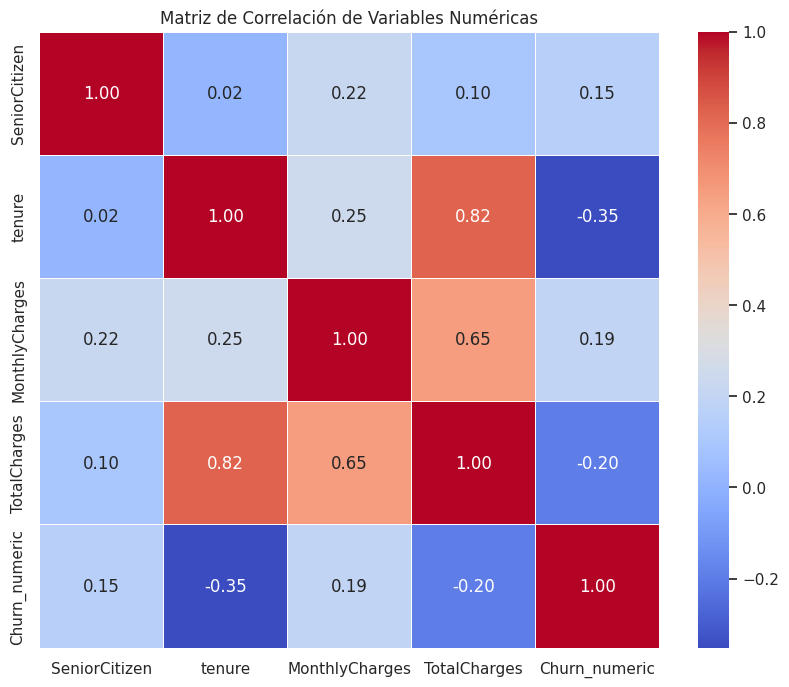

In [239]:
# 3. Matriz de correlación para las variables numéricas
# Convertir 'Churn' a numérico para la correlación
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identificar columnas numéricas para la correlación (excluyendo Churn_numeric temporalmente)
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn_numeric' in numeric_cols_for_corr: # Ensure it's not double counted if already numeric
    numeric_cols_for_corr.remove('Churn_numeric')

correlation_matrix = df[numeric_cols_for_corr + ['Churn_numeric']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Eliminar la columna auxiliar 'Churn_numeric' para mantener el DataFrame original
df = df.drop('Churn_numeric', axis=1)

## 6. Preparación de Características (Feature Engineering de base)

Dejamos los datos listos en el formato que los algoritmos de Machine Learning necesitan (numéricos y escalados si es necesario).

In [240]:
# 1. Codificación de variables categóricas (Ej: One-Hot Encoding)
# Identificar columnas categóricas
categorical_cols_to_encode = df.select_dtypes(include='object').columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# 2. Separación en Variables Predictoras (X) y Variable Objetivo (y)
# La variable 'Churn' ya ha sido manejada (si se transformó a numérico en EDA para correlación,
# aquí usamos la columna original o la codificada directamente).

# Asumiendo que 'Churn' en df_encoded es 'Yes_Yes' (después de get_dummies) o ya es binaria si se codificó manualmente
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

print("Estructura final de los datos lista para el split de entrenamiento.")
display(X.head())
display(y.head())

Estructura final de los datos lista para el split de entrenamiento.


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


,Churn_Yes
0,False
1,False
2,True
3,False
4,True


## 7. Conclusiones del EDA y Siguientes Pasos

Esta es la sección más "humana". Escribe un resumen ejecutivo con viñetas de los hallazgos más relevantes y las decisiones tomadas durante el proceso de EDA y limpieza.

- **Hallazgo 1:** La distribución de `Churn` muestra un desbalance de clases, lo cual es común en problemas de clasificación y deberá ser abordado en la fase de modelado (e.g., sobremuestreo, submuestreo, o ajuste de pesos de clase).
- **Hallazgo 2:** Variables como `Contract`, `OnlineSecurity`, `TechSupport` y `InternetService` muestran una fuerte relación con el `Churn`, indicando que son factores importantes para la rotación de clientes.
- **Hallazgo 3:** La columna `TotalCharges` presentaba valores en blanco que fueron interpretados como texto y convertidos a `NaN`, y luego imputados con la media, lo que asegura que la columna sea numérica y completa.
- **Decisión de Limpieza:** Se eliminó la columna `customerID` ya que es un identificador único sin valor predictivo directo y se eliminaron filas duplicadas para asegurar la unicidad de los datos.
- **Próximo paso:** Exportar el dataset limpio y preprocesado (`teleco_clean.csv`) para proceder a la división Train/Test y al desarrollo de modelos de Machine Learning.

## Guardado de Datos Limpios

Una vez finalizada la limpieza y el EDA, guardamos el DataFrame procesado en un nuevo archivo CSV. Esto asegura que los pasos de preprocesamiento no necesiten ser repetidos en futuros análisis o en la fase de modelado.

In [241]:
import os

# Crear la carpeta data/processed si no existe
output_dir = './data/processed'
os.makedirs(output_dir, exist_ok=True)

# Guardar el DataFrame procesado
output_path = os.path.join(output_dir, 'teleco_clean.csv')
df.to_csv(output_path, index=False)

print(f"Datos limpios guardados en: {output_path}")

Datos limpios guardados en: ./data/processed/teleco_clean.csv
